In [1]:
#imports
import numpy as np
from numpy import random as rng

from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
from tqdm import tqdm
from utils import compare_thetas,lambda_b_bound, lambda_s_bound, compute_g_min,theta_lasso,theta_1_inf, \
                dirty_trial, lasso_trial, inf_trial, extract_n_values, find_threshold_crossing, dirty_resutls,lasso_results, inf_results,application_1_plot
                
from sklearn.model_selection import KFold

# Synthetic Data Simulation


In [2]:

p = 128  # total features
n = 80  # samples per task
N = range(33,267)
r = 2         # number of tasks
s = int(p/10)         # sparsity per task
sigma = 0.1

alpha = 0.8   # overlap fraction
lambda_s = 0.1
lambda_b = 0.2
lambda_lasso = 0.1
lambda_inf = 0.05

n_trials = 100
N = np.arange(33,250)
gmin = compute_g_min(sigma, r, s, n,lambda_s, C_min = 1, D_max = 1 )
#print(f'{n/(s * np.log(p - (2-alpha) * s ))=}')
print(f'lambda_s_bound: {lambda_s_bound(sigma,s,n,r,p,alpha)}')
print(f'lambda_b_bound: {lambda_b_bound(sigma,s,n,r,p,alpha)}')
print(f'gmin: {compute_g_min(sigma, r, s, n,lambda_s, C_min = 1, D_max = 1 )}')
print(f'theta_1_inf: {theta_1_inf(n,p,s,alpha).item()} | theta_lasso: {theta_lasso(n, p, s).item() }')

lambda_s_bound: -0.1085600676183361
lambda_b_bound: -0.1401842473472932
gmin: 0.7775918900934162
theta_1_inf: 1.4086440933162865 | theta_lasso: 1.4024487594954094


# Finetuning the parameters 

### Dirty

when $\alpha$ is big $\lambda_b$ should be big

In [3]:
lambda_s = 0.1
lambda_b = 0.2
np.random.seed(42)

sucess: 96/100: 100%|██████████| 100/100 [00:06<00:00, 16.09it/s]


96

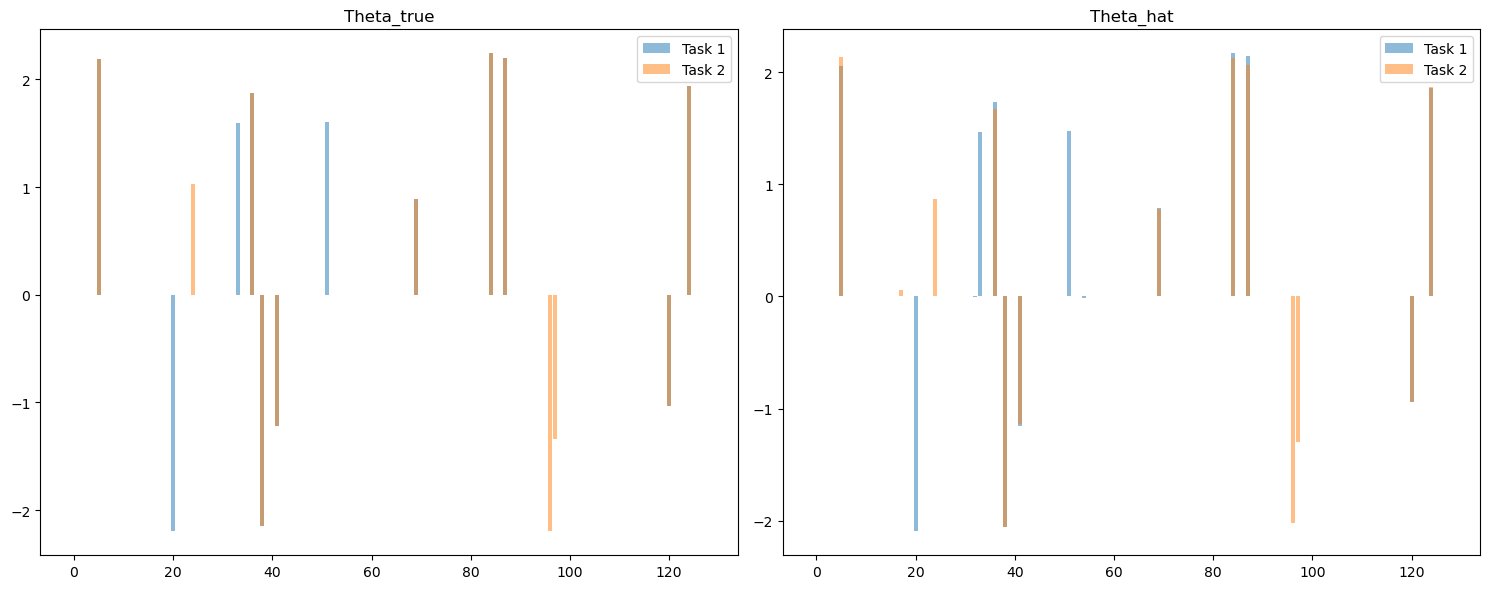

In [20]:
success = 0
pbar = tqdm(range(100),dynamic_ncols=True)
for i in pbar:
    if dirty_trial(n,p,r,s,lambda_b,lambda_s,alpha,sigma,gmin):
        success +=1
        #print('+1')
    pbar.set_description(f'sucess: {success}/{i+1}')

Theta_true,Theta_hat, _  =  dirty_trial(n,p,r,s,lambda_b,lambda_s,alpha,sigma,gmin, return_params=True)
compare_thetas(Theta_true,Theta_hat)
success

### Lasso



sucess: 98/100: 100%|██████████| 100/100 [00:02<00:00, 37.04it/s]


98

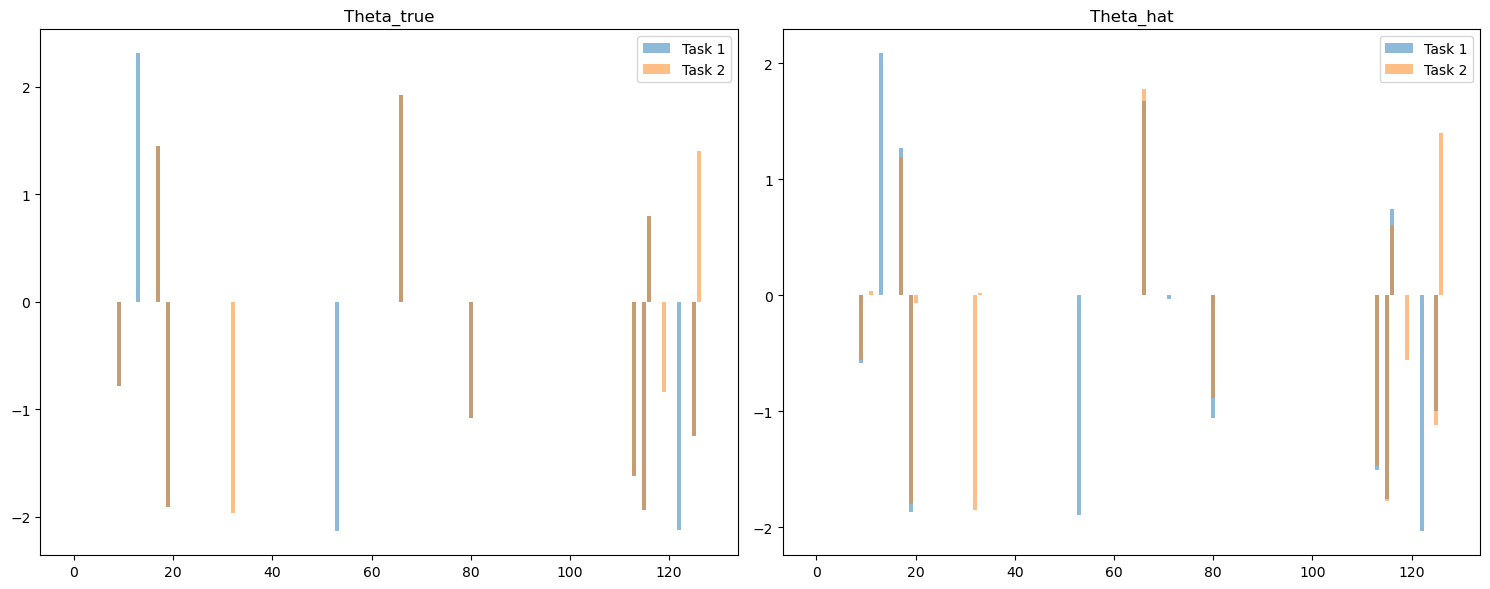

In [21]:
np.random.seed(42)
success = 0
pbar = tqdm(range(100),dynamic_ncols=True)
for i in pbar:
    if lasso_trial(n,p,r,s,lambda_lasso,alpha,sigma,gmin):
        success +=1
        #print('+1')
    pbar.set_description(f'sucess: {success}/{i+1}')

Theta_true,Theta_hat, _  =  dirty_trial(n,p,r,s,lambda_b,lambda_s,alpha,sigma,gmin, return_params=True)
compare_thetas(Theta_true,Theta_hat)
success

## 1/inf


In [22]:
lambda_1inf = 0.05

sucess: 100/100: 100%|██████████| 100/100 [00:05<00:00, 19.85it/s]


True

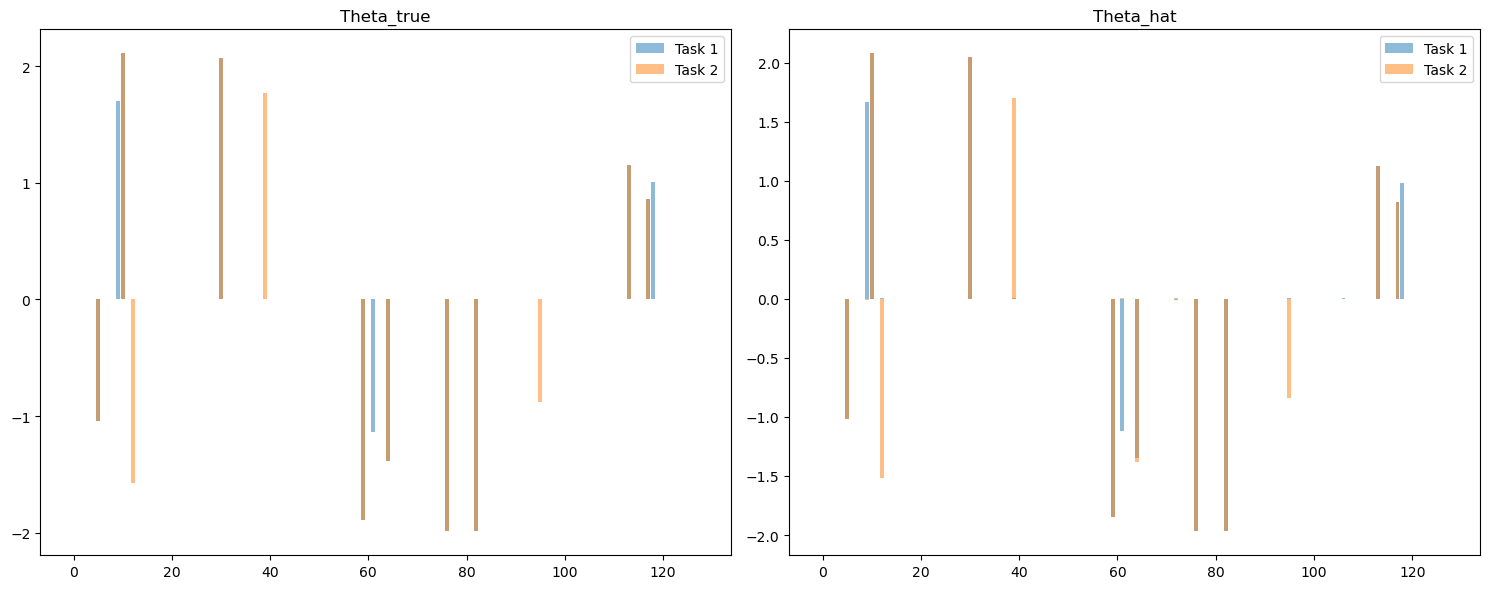

In [23]:
np.random.seed(42)
N = 1000
success = 0
pbar = tqdm(range(100),dynamic_ncols=True)
for i in pbar:
    if inf_trial(n,p,r,s,lambda_1inf,alpha,sigma,gmin):
        success +=1
        #print('+1')
    pbar.set_description(f'sucess: {success}/{i+1}')

Theta_true,Theta_hat,success = inf_trial(n,p,r,s,lambda_1inf,alpha,sigma,gmin,return_params=True)
compare_thetas(Theta_true,Theta_hat)
success

# Making plot 

In [3]:

n_range = np.arange(33,250)
alphas = [0.3,2/3,0.8]
lambda_s = 0.1
lambda_b = 0.2
lambda_lasso = 0.1
lambda_inf = 0.05
n_trials = 100
sigma = 0.1
p = 128
s = int(p/10)

In [8]:
inf_dict

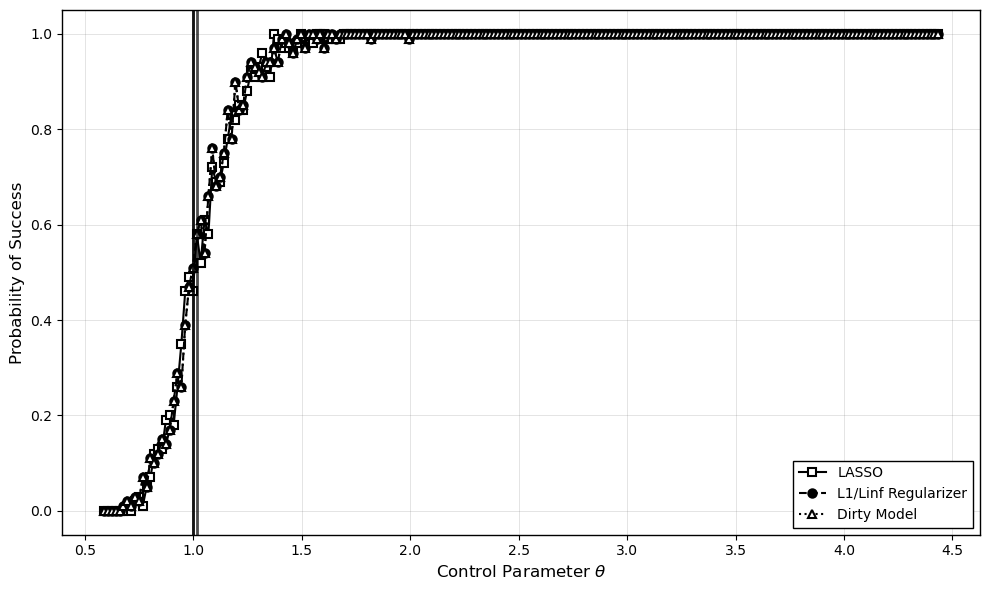

In [12]:
application_1_plot(dirty_dict,dirty_dict,lasso_dict,p,s,alpha,filename)

--------------------------------------------------
alpha = 0.3


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:04<00:00, 23.49it/s]
success: 0/100 | n = 34/249: 100%|██████████| 100/100 [00:04<00:00, 23.88it/s]
success: 0/100 | n = 35/249: 100%|██████████| 100/100 [00:04<00:00, 23.54it/s]
success: 0/100 | n = 36/249: 100%|██████████| 100/100 [00:04<00:00, 23.68it/s]
success: 1/100 | n = 37/249: 100%|██████████| 100/100 [00:04<00:00, 23.75it/s]
success: 0/100 | n = 38/249: 100%|██████████| 100/100 [00:04<00:00, 23.76it/s]
success: 0/100 | n = 39/249: 100%|██████████| 100/100 [00:04<00:00, 23.84it/s]
success: 0/100 | n = 40/249: 100%|██████████| 100/100 [00:04<00:00, 23.88it/s]
success: 1/100 | n = 41/249: 100%|██████████| 100/100 [00:04<00:00, 23.39it/s]
success: 0/100 | n = 42/249: 100%|██████████| 100/100 [00:04<00:00, 23.51it/s]
success: 4/100 | n = 43/249: 100%|██████████| 100/100 [00:04<00:00, 22.98it/s]
success: 5/100 | n = 44/249: 100%|██████████| 100/100 [00:04<00:00, 22.26it/s]
success: 9/100 | n = 45/249: 100%|██████████| 100/10

10 consecutive perfect results up to n=127. Filling rest with 1.0...


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:02<00:00, 43.68it/s]
success: 0/100 | n = 34/249: 100%|██████████| 100/100 [00:02<00:00, 42.96it/s]
success: 0/100 | n = 35/249: 100%|██████████| 100/100 [00:02<00:00, 41.68it/s]
success: 0/100 | n = 36/249: 100%|██████████| 100/100 [00:02<00:00, 43.41it/s]
success: 0/100 | n = 37/249: 100%|██████████| 100/100 [00:02<00:00, 43.24it/s]
success: 1/100 | n = 38/249: 100%|██████████| 100/100 [00:02<00:00, 43.51it/s]
success: 1/100 | n = 39/249: 100%|██████████| 100/100 [00:02<00:00, 43.29it/s]
success: 1/100 | n = 40/249: 100%|██████████| 100/100 [00:02<00:00, 42.07it/s]
success: 1/100 | n = 41/249: 100%|██████████| 100/100 [00:02<00:00, 42.68it/s]
success: 2/100 | n = 42/249: 100%|██████████| 100/100 [00:02<00:00, 41.60it/s]
success: 3/100 | n = 43/249: 100%|██████████| 100/100 [00:02<00:00, 40.98it/s]
success: 2/100 | n = 44/249: 100%|██████████| 100/100 [00:02<00:00, 40.66it/s]
success: 9/100 | n = 45/249: 100%|██████████| 100/10

10 consecutive perfect Lasso runs up to n=115. Filling rest with 1.0.


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:03<00:00, 27.86it/s]
success: 0/100 | n = 34/249: 100%|██████████| 100/100 [00:03<00:00, 27.79it/s]
success: 0/100 | n = 35/249: 100%|██████████| 100/100 [00:03<00:00, 26.99it/s]
success: 0/100 | n = 36/249: 100%|██████████| 100/100 [00:03<00:00, 26.58it/s]
success: 0/100 | n = 37/249: 100%|██████████| 100/100 [00:03<00:00, 26.16it/s]
success: 0/100 | n = 38/249: 100%|██████████| 100/100 [00:03<00:00, 26.49it/s]
success: 0/100 | n = 39/249: 100%|██████████| 100/100 [00:03<00:00, 25.90it/s]
success: 0/100 | n = 40/249: 100%|██████████| 100/100 [00:03<00:00, 26.06it/s]
success: 0/100 | n = 41/249: 100%|██████████| 100/100 [00:03<00:00, 25.33it/s]
success: 0/100 | n = 42/249: 100%|██████████| 100/100 [00:03<00:00, 25.42it/s]
success: 0/100 | n = 43/249: 100%|██████████| 100/100 [00:03<00:00, 25.09it/s]
success: 0/100 | n = 44/249: 100%|██████████| 100/100 [00:03<00:00, 25.08it/s]
success: 0/100 | n = 45/249: 100%|██████████| 100/10

10 consecutive perfect runs (inf) up to n=126. Filling remaining with 1.0.


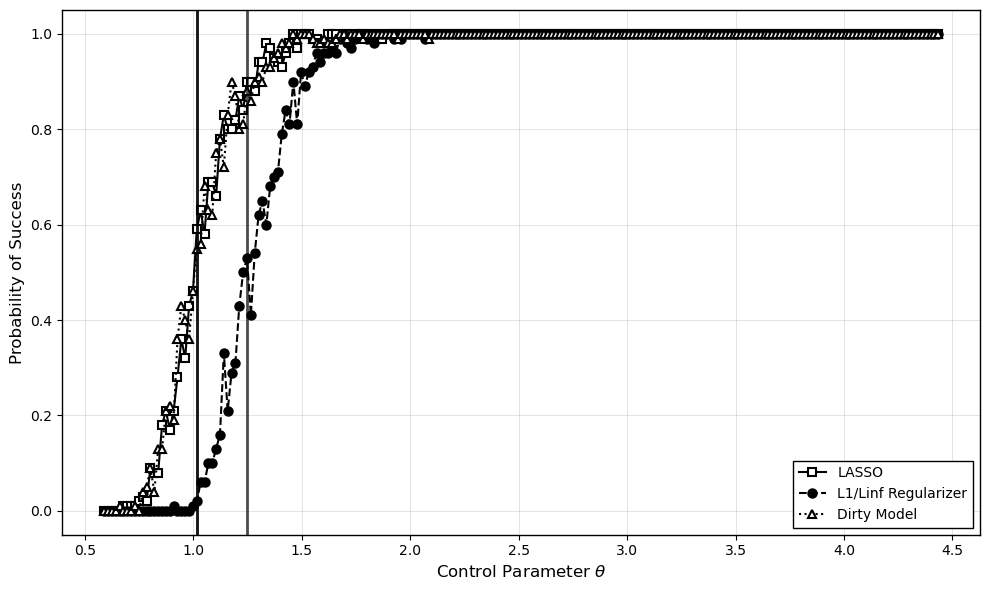

--------------------------------------------------
alpha = 0.6666666666666666


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:04<00:00, 23.02it/s]
success: 0/100 | n = 34/249: 100%|██████████| 100/100 [00:04<00:00, 21.83it/s]
success: 0/100 | n = 35/249: 100%|██████████| 100/100 [00:04<00:00, 22.81it/s]
success: 0/100 | n = 36/249: 100%|██████████| 100/100 [00:04<00:00, 23.47it/s]
success: 0/100 | n = 37/249: 100%|██████████| 100/100 [00:04<00:00, 23.43it/s]
success: 0/100 | n = 38/249: 100%|██████████| 100/100 [00:04<00:00, 24.02it/s]
success: 0/100 | n = 39/249: 100%|██████████| 100/100 [00:04<00:00, 24.23it/s]
success: 1/100 | n = 40/249: 100%|██████████| 100/100 [00:04<00:00, 23.89it/s]
success: 6/100 | n = 41/249: 100%|██████████| 100/100 [00:04<00:00, 23.76it/s]
success: 3/100 | n = 42/249: 100%|██████████| 100/100 [00:04<00:00, 23.28it/s]
success: 1/100 | n = 43/249: 100%|██████████| 100/100 [00:04<00:00, 22.48it/s]
success: 4/100 | n = 44/249: 100%|██████████| 100/100 [00:04<00:00, 22.05it/s]
success: 6/100 | n = 45/249: 100%|██████████| 100/10

10 consecutive perfect results up to n=107. Filling rest with 1.0...


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:02<00:00, 42.62it/s]
success: 0/100 | n = 34/249: 100%|██████████| 100/100 [00:02<00:00, 41.34it/s]
success: 1/100 | n = 35/249: 100%|██████████| 100/100 [00:02<00:00, 40.71it/s]
success: 0/100 | n = 36/249: 100%|██████████| 100/100 [00:02<00:00, 43.49it/s]
success: 0/100 | n = 37/249: 100%|██████████| 100/100 [00:02<00:00, 42.73it/s]
success: 2/100 | n = 38/249: 100%|██████████| 100/100 [00:02<00:00, 42.75it/s]
success: 1/100 | n = 39/249: 100%|██████████| 100/100 [00:02<00:00, 43.34it/s]
success: 1/100 | n = 40/249: 100%|██████████| 100/100 [00:02<00:00, 42.02it/s]
success: 2/100 | n = 41/249: 100%|██████████| 100/100 [00:02<00:00, 41.49it/s]
success: 6/100 | n = 42/249: 100%|██████████| 100/100 [00:02<00:00, 39.36it/s]
success: 5/100 | n = 43/249: 100%|██████████| 100/100 [00:02<00:00, 40.63it/s]
success: 6/100 | n = 44/249: 100%|██████████| 100/100 [00:02<00:00, 39.86it/s]
success: 10/100 | n = 45/249: 100%|██████████| 100/1

10 consecutive perfect Lasso runs up to n=106. Filling rest with 1.0.


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:03<00:00, 27.98it/s]
success: 0/100 | n = 34/249: 100%|██████████| 100/100 [00:03<00:00, 27.53it/s]
success: 3/100 | n = 35/249: 100%|██████████| 100/100 [00:03<00:00, 26.94it/s]
success: 1/100 | n = 36/249: 100%|██████████| 100/100 [00:03<00:00, 26.45it/s]
success: 4/100 | n = 37/249: 100%|██████████| 100/100 [00:03<00:00, 26.15it/s]
success: 6/100 | n = 38/249: 100%|██████████| 100/100 [00:03<00:00, 25.39it/s]
success: 13/100 | n = 39/249: 100%|██████████| 100/100 [00:04<00:00, 24.84it/s]
success: 13/100 | n = 40/249: 100%|██████████| 100/100 [00:04<00:00, 24.03it/s]
success: 16/100 | n = 41/249: 100%|██████████| 100/100 [00:04<00:00, 23.73it/s]
success: 19/100 | n = 42/249: 100%|██████████| 100/100 [00:04<00:00, 22.50it/s]
success: 28/100 | n = 43/249: 100%|██████████| 100/100 [00:04<00:00, 22.20it/s]
success: 34/100 | n = 44/249: 100%|██████████| 100/100 [00:04<00:00, 20.36it/s]
success: 45/100 | n = 45/249: 100%|██████████|

10 consecutive perfect runs (inf) up to n=82. Filling remaining with 1.0.


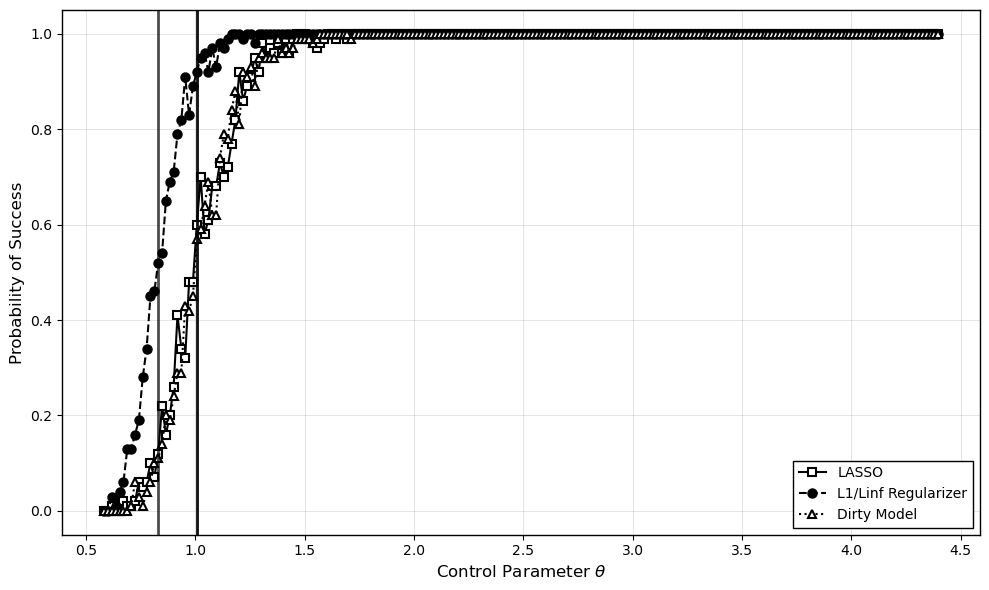

--------------------------------------------------
alpha = 0.8


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:04<00:00, 23.50it/s]
success: 0/100 | n = 34/249: 100%|██████████| 100/100 [00:04<00:00, 22.98it/s]
success: 0/100 | n = 35/249: 100%|██████████| 100/100 [00:04<00:00, 24.66it/s]
success: 0/100 | n = 36/249: 100%|██████████| 100/100 [00:04<00:00, 24.83it/s]
success: 0/100 | n = 37/249: 100%|██████████| 100/100 [00:04<00:00, 23.42it/s]
success: 0/100 | n = 38/249: 100%|██████████| 100/100 [00:04<00:00, 24.48it/s]
success: 0/100 | n = 39/249: 100%|██████████| 100/100 [00:04<00:00, 24.64it/s]
success: 1/100 | n = 40/249: 100%|██████████| 100/100 [00:04<00:00, 23.50it/s]
success: 1/100 | n = 41/249: 100%|██████████| 100/100 [00:04<00:00, 22.84it/s]
success: 2/100 | n = 42/249: 100%|██████████| 100/100 [00:04<00:00, 23.05it/s]
success: 5/100 | n = 43/249: 100%|██████████| 100/100 [00:04<00:00, 23.62it/s]
success: 2/100 | n = 44/249: 100%|██████████| 100/100 [00:04<00:00, 23.15it/s]
success: 9/100 | n = 45/249: 100%|██████████| 100/10

10 consecutive perfect results up to n=111. Filling rest with 1.0...


success: 0/100 | n = 33/249: 100%|██████████| 100/100 [00:02<00:00, 40.78it/s]
success: 1/100 | n = 34/249: 100%|██████████| 100/100 [00:02<00:00, 42.88it/s]
success: 0/100 | n = 35/249: 100%|██████████| 100/100 [00:02<00:00, 42.51it/s]
success: 0/100 | n = 36/249: 100%|██████████| 100/100 [00:02<00:00, 42.85it/s]
success: 0/100 | n = 37/249: 100%|██████████| 100/100 [00:02<00:00, 44.04it/s]
success: 0/100 | n = 38/249: 100%|██████████| 100/100 [00:02<00:00, 42.92it/s]
success: 0/100 | n = 39/249: 100%|██████████| 100/100 [00:02<00:00, 42.49it/s]
success: 0/100 | n = 40/249: 100%|██████████| 100/100 [00:02<00:00, 42.89it/s]
success: 0/100 | n = 41/249: 100%|██████████| 100/100 [00:02<00:00, 42.31it/s]
success: 3/100 | n = 42/249: 100%|██████████| 100/100 [00:02<00:00, 42.50it/s]
success: 3/100 | n = 43/249: 100%|██████████| 100/100 [00:02<00:00, 41.15it/s]
success: 5/100 | n = 44/249: 100%|██████████| 100/100 [00:02<00:00, 40.35it/s]
success: 7/100 | n = 45/249: 100%|██████████| 100/10

10 consecutive perfect Lasso runs up to n=101. Filling rest with 1.0.


success: 4/100 | n = 33/249: 100%|██████████| 100/100 [00:03<00:00, 27.20it/s]
success: 11/100 | n = 34/249: 100%|██████████| 100/100 [00:03<00:00, 25.93it/s]
success: 7/100 | n = 35/249: 100%|██████████| 100/100 [00:03<00:00, 26.67it/s]
success: 24/100 | n = 36/249: 100%|██████████| 100/100 [00:04<00:00, 24.99it/s]
success: 17/100 | n = 37/249: 100%|██████████| 100/100 [00:03<00:00, 25.02it/s]
success: 25/100 | n = 38/249: 100%|██████████| 100/100 [00:04<00:00, 24.74it/s]
success: 32/100 | n = 39/249: 100%|██████████| 100/100 [00:04<00:00, 23.49it/s]
success: 34/100 | n = 40/249: 100%|██████████| 100/100 [00:04<00:00, 22.88it/s]
success: 49/100 | n = 41/249: 100%|██████████| 100/100 [00:04<00:00, 22.37it/s]
success: 50/100 | n = 42/249: 100%|██████████| 100/100 [00:04<00:00, 21.82it/s]
success: 68/100 | n = 43/249: 100%|██████████| 100/100 [00:04<00:00, 21.59it/s]
success: 59/100 | n = 44/249: 100%|██████████| 100/100 [00:04<00:00, 20.87it/s]
success: 65/100 | n = 45/249: 100%|███████

10 consecutive perfect runs (inf) up to n=81. Filling remaining with 1.0.


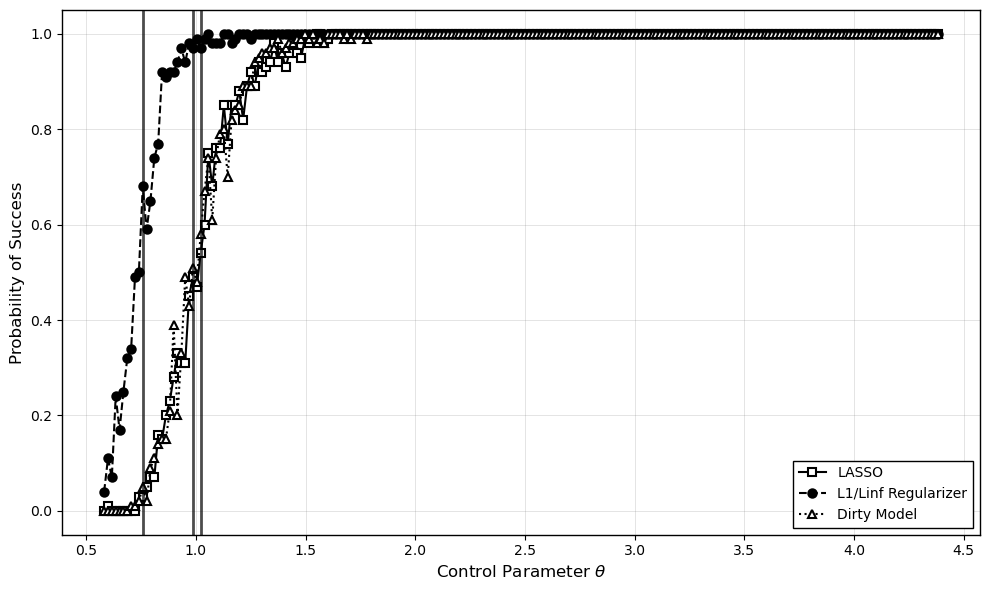

In [4]:

n_range = np.arange(33,250)
alphas = [0.3,2/3,0.8]
lambda_s = 0.1
lambda_b = 0.2
lambda_lasso = 0.1
lambda_inf = 0.05
n_trials = 100
sigma = 0.1
p = 128
s = int(p/10)

for alpha in alphas:
    print('-'*50)
    print(f'alpha = {alpha}')


    dirty_dict  = dirty_resutls(n_range,n_trials,sigma,p ,r,s,lambda_s, lambda_b, alpha)
    lasso_dict = lasso_results(n_range,n_trials,sigma,p,r,s,lambda_s,lambda_lasso,alpha)
    inf_dict = inf_results(n_range,n_trials,sigma,p,r,s,lambda_s,lambda_inf,alpha)
    safe_alpha = str(alpha).replace('.', '_')  
    filename = f'Probability_of_success_alpha_{safe_alpha}'
    application_1_plot(dirty_dict,inf_dict,lasso_dict,p,s,alpha,filename)
